In [27]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals


sys.path.append("/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/AllInOne_2022/Trial_dxy_pT_Resolution_dask.coffea"
# f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/BigSamples_2022/Futures_Resolution.coffea"

sig_histo = util.load(f_sig) [0]
# sig_histo

                                       mchi  dmchi   ctau    m1    m2  delta  \
sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  11.0    2.0  100.0  10.0  12.0    0.2   

                                                                        name  
sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  sig_2022_Mchi-11p0_dMchi-2p0_ctau-100  
                                       mchi  dmchi   ctau    m1    m2  delta  \
sig_2022_Mchi-22p0_dMchi-4p0_ctau-100  22.0    4.0  100.0  20.0  24.0    0.2   

                                                                        name  
sig_2022_Mchi-22p0_dMchi-4p0_ctau-100  sig_2022_Mchi-22p0_dMchi-4p0_ctau-100  
                                       mchi  dmchi   ctau    m1    m2  delta  \
sig_2022_Mchi-33p0_dMchi-6p0_ctau-100  33.0    6.0  100.0  30.0  36.0    0.2   

                                                                        name  
sig_2022_Mchi-33p0_dMchi-6p0_ctau-100  sig_2022_Mchi-33p0_dMchi-6p0_ctau-100  
                                       mchi

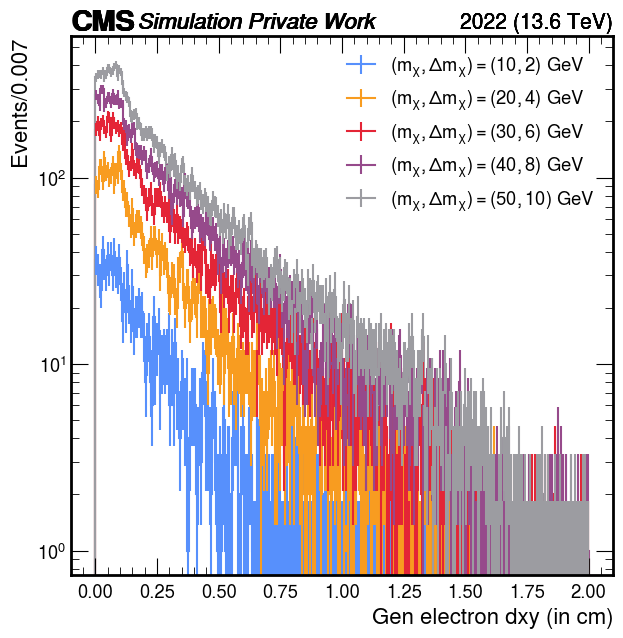

In [29]:
fig, ax = plt.subplots(figsize=(7,7))

# Plot settings
plot_dict = {
    'variable':'dxy_gen',
    'cut': 'cut1',
    'year': 2022
}
style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "Gen electron dxy (in cm)",
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points

samples = {
    10: 
    {
        
        0.2: [100],
    },
    20: 
    {
        
        0.2: [100],
        
    },
    30: 
    {
       
        0.2: [100]
    },
    40: 
    {
        0.2: [100],
    },
    50:
    {
        
        0.2: [100],
    },
    # 60:
    # {
        
    #      0.1: [100],
    #      0.2: [100]
    
    # },
    # 70:
    # {    0.1: [100],
    #      0.2: [100],
    # },
    # 80:
    # {    0.1: [100],
    #      0.2: [100],
    # },
    # 90:
    # {    0.1: [100],
    #      0.2: [100],
    # },
    # 100:
    # {    0.1: [100],
    #      0.2: [100],
    # }
 
}


# ptools.plot_signal_1D_return_histo(sig_histo, m1, delta, ctau, plot_dict, style_dict)

h_list_lpt=[]
h_sum_lpt = None   #Dont

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_1D_return_histo(sig_histo, m1, delta, ctau, plot_dict, style_dict)
            h_list_lpt.append(h_lpt)
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
            else:
                h_sum_lpt += h_lpt

counts_lpt = h_sum_lpt.values()
edges_lpt = h_sum_lpt.axes[0].edges

# bin_x_lpt = (edges_lpt[1:]+edges_lpt[:-1])/2



# variances_lpt = h_sum_lpt.variances()
# yerr_lpt = np.sqrt(variances_lpt)

# print (type(h_lpt))


sig_2022_Mchi-11p0_dMchi-2p0_ctau-100
Hist(
  Variable([0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2], name='Gen_pt_res'),
  Regular(700, -0.5, 0.5, name='Res_GED'),
  storage=Weight()) # Sum: WeightedSum(value=1242, variance=1242) (WeightedSum(value=2506, variance=2506) with flow)
sig_2022_Mchi-22p0_dMchi-4p0_ctau-100
sig_2022_Mchi-33p0_dMchi-6p0_ctau-100
sig_2022_Mchi-44p0_dMchi-8p0_ctau-100
sig_2022_Mchi-55p0_dMchi-10p0_ctau-100
sig_2022_Mchi-63p0_dMchi-6p0_ctau-100
sig_2022_Mchi-66p0_dMchi-12p0_ctau-100
sig_2022_Mchi-73p5_dMchi-7p0_ctau-100
sig_2022_Mchi-77p0_dMchi-14p0_ctau-100
sig_2022_Mchi-84p0_dMchi-8p0_ctau-100
sig_2022_Mchi-88p0_dMchi-16p0_ctau-100
sig_2022_Mchi-94p5_dMchi-9p0_ctau-100
sig_2022_Mchi-99p0_dMchi-18p0_ctau-100
sig_2022_Mchi-105p0_dMchi-10p0_ctau-100
sig_2022_Mchi-110p0_dMchi-20p0_ctau-100


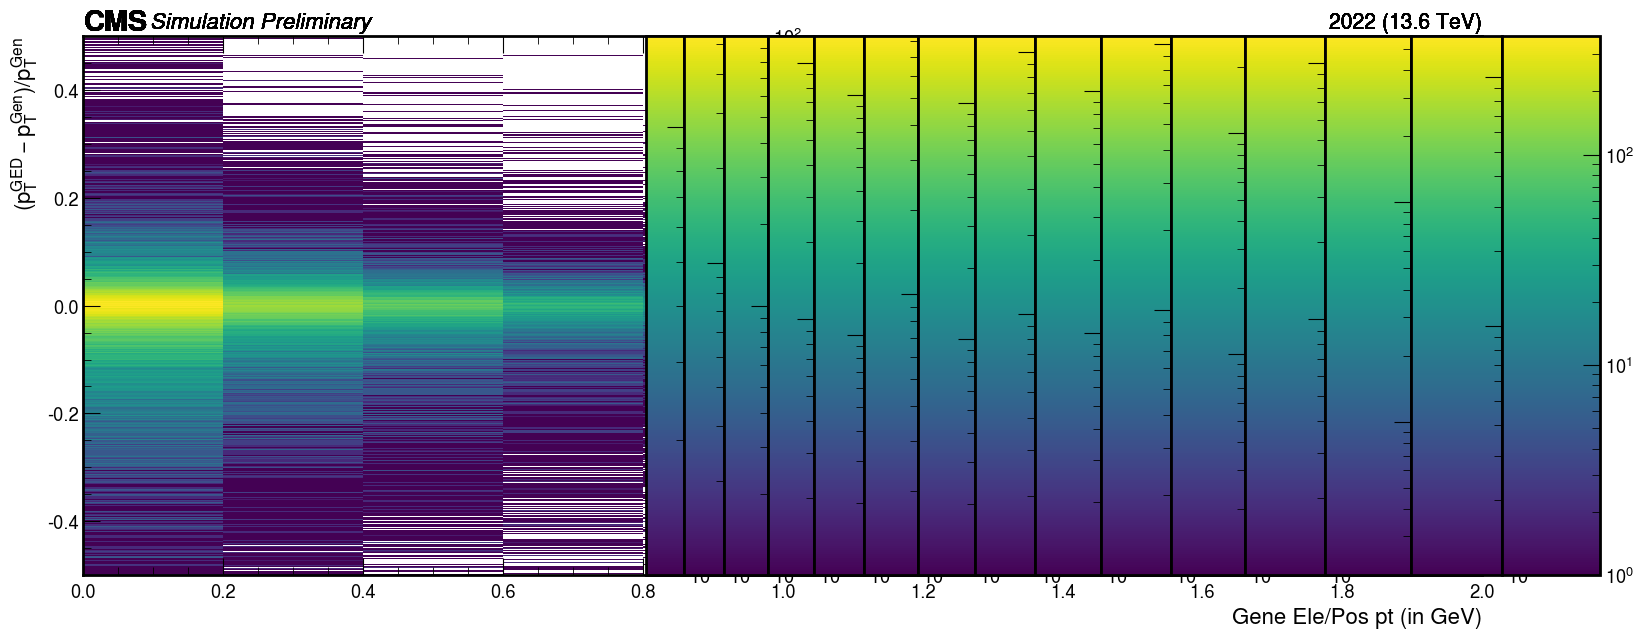

In [30]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_GED_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}


samples = {
    10: 
    {
        
        0.2: [100],
    },
    20: 
    {
        
        0.2: [100],
        
    },
    30: 
    {
       
        0.2: [100]
    },
    40: 
    {
        0.2: [100],
    },
    50:
    {
        
        0.2: [100],
    },
    60:
    {
        
         0.1: [100],
         0.2: [100]
    
    },
    70:
    {    0.1: [100],
         0.2: [100],
    },
    80:
    {    0.1: [100],
         0.2: [100],
    },
    90:
    {    0.1: [100],
         0.2: [100],
    },
    100:
    {    0.1: [100],
         0.2: [100],
    }
 
}

h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
                print (h_sum_lpt)
            else:
                h_sum_lpt += h_lpt



In [31]:
# ============================================================
# TUNABLE HISTOGRAM / FIT / PLOT SETTINGS
# ============================================================
# The histogram is already stored in the .coffea file, so in this notebook
# we can make the residual bins wider by combining existing bins.
# We cannot make them finer than the original stored bin width.

# Desired residual-bin width. Set to None to keep the original binning.
res_bin_width = 0.01

# Residual range used by curve_fit (this affects the fitted result).
fit_min = -0.30
fit_max =  0.30

# Residual x-axis range shown on each fit plot (display only).
plot_min = -0.50
plot_max =  0.50

# ----- Build the histogram that will be used below -----
h_fit_lpt = h_sum_lpt

original_edges = h_sum_lpt.axes[1].edges
original_widths = np.diff(original_edges)

if res_bin_width is not None:
    # Automatic rebinning below assumes the stored residual axis has uniform bins.
    if not np.allclose(original_widths, original_widths[0]):
        raise ValueError(
            "The stored residual axis has variable-width bins. "
            "Use an explicit grouping/rebinning scheme instead of res_bin_width."
        )

    original_bin_width = original_widths[0]
    rebin_factor = int(round(res_bin_width / original_bin_width))

    if rebin_factor < 1:
        raise ValueError(
            f"Requested bin width {res_bin_width:g} is finer than the stored "
            f"bin width {original_bin_width:g}. The .coffea histogram must be "
            "created with finer bins upstream if you want that."
        )

    actual_bin_width = rebin_factor * original_bin_width
    if not np.isclose(actual_bin_width, res_bin_width):
        raise ValueError(
            f"Requested bin width {res_bin_width:g} is not an integer multiple "
            f"of the stored width {original_bin_width:g}. Try one of "
            f"{original_bin_width:g}, {2*original_bin_width:g}, "
            f"{3*original_bin_width:g}, ..."
        )

    h_fit_lpt = h_sum_lpt[:, hist.rebin(rebin_factor)]
    print(f"Original residual bin width : {original_bin_width:g}")
    print(f"Rebin factor                : {rebin_factor}")
    print(f"Residual bin width used     : {actual_bin_width:g}")
else:
    print("Using the original residual binning.")

print(f"Fit range                   : [{fit_min}, {fit_max}]")
print(f"Displayed x range           : [{plot_min}, {plot_max}]")


Original residual bin width : 0.00142857
Rebin factor                : 7
Residual bin width used     : 0.01
Fit range                   : [-0.3, 0.3]
Displayed x range           : [-0.5, 0.5]


In [32]:
#When NO GROUPING:
first_data = []
# print ("Gen pT bins=", h_fit_lpt.axes[0].edges) 
# print ("Resolution pT bins=", h_fit_lpt.axes[1].edges)


totalnumber_genpt_bins = len(h_fit_lpt.axes[0].edges)-1

for genpt_bin_index in range(totalnumber_genpt_bins):
    ptbin_index = genpt_bin_index
    genptbin_range = (h_fit_lpt.axes[0].edges [genpt_bin_index], h_fit_lpt.axes[0].edges [genpt_bin_index+1])
    counts = h_fit_lpt[genpt_bin_index, :].values() 
    bin_edges = h_fit_lpt.axes[1].edges
    bincenters = (bin_edges[1:]+bin_edges[:-1])/2

    

    # bin_edges = h_sum_lpt_rebinned[genpt_bin_index, :].axes[1].edges
    # bincenters = (bin_edges[1:]+bin_edges[:-1])/2 
    
    variances = h_fit_lpt[genpt_bin_index, :].variances() 
    yerr = np.sqrt(variances)

    first_data.append({"ptbin_index": ptbin_index, "genpt_bin":genptbin_range, "xdata": bincenters, "ydata": counts, "yerror": yerr} )
    
    
first_data


[{'ptbin_index': 0,
  'genpt_bin': (0.0, 0.2),
  'xdata': array([-0.495, -0.485, -0.475, -0.465, -0.455, -0.445, -0.435, -0.425,
         -0.415, -0.405, -0.395, -0.385, -0.375, -0.365, -0.355, -0.345,
         -0.335, -0.325, -0.315, -0.305, -0.295, -0.285, -0.275, -0.265,
         -0.255, -0.245, -0.235, -0.225, -0.215, -0.205, -0.195, -0.185,
         -0.175, -0.165, -0.155, -0.145, -0.135, -0.125, -0.115, -0.105,
         -0.095, -0.085, -0.075, -0.065, -0.055, -0.045, -0.035, -0.025,
         -0.015, -0.005,  0.005,  0.015,  0.025,  0.035,  0.045,  0.055,
          0.065,  0.075,  0.085,  0.095,  0.105,  0.115,  0.125,  0.135,
          0.145,  0.155,  0.165,  0.175,  0.185,  0.195,  0.205,  0.215,
          0.225,  0.235,  0.245,  0.255,  0.265,  0.275,  0.285,  0.295,
          0.305,  0.315,  0.325,  0.335,  0.345,  0.355,  0.365,  0.375,
          0.385,  0.395,  0.405,  0.415,  0.425,  0.435,  0.445,  0.455,
          0.465,  0.475,  0.485,  0.495]),
  'ydata': array([5.2000e

In [33]:
for data in first_data:
    x = data["xdata"]
    y = data["ydata"]
    sig = data["yerror"]
    index = data["ptbin_index"]

    # Keep only populated bins inside the chosen fit range.
    # Changing fit_min / fit_max changes which points are given to curve_fit.
    mask = (y > 0) & (x >= fit_min) & (x <= fit_max)

    data["y_new_data"] = y[mask]
    data["x_new_data"] = x[mask]
    data["yerr_new_data"] = sig[mask]


In [34]:
first_data = [data for data in first_data
              if (len(data["y_new_data"]) )> 0]
# first_data

In [35]:
n_parameters = 7
first_data = [data for data in first_data
              if (len(data["y_new_data"]) )> n_parameters]
# first_data

In [36]:
#1. Define your model

def double_cb(x,u,sig, nl, a_l, nr, a_r,N):
    
    t=(x-u)/(sig)
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t>= -al) & (t<=ar)
    right_tail = t > ar

    y=np.empty_like(t)

    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl / al)**nl * np.exp(-0.5 * al**2)
    B_L = (nl / al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr / ar)**nr * np.exp(-0.5 * ar**2)
    B_R = (nr / ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y


0


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


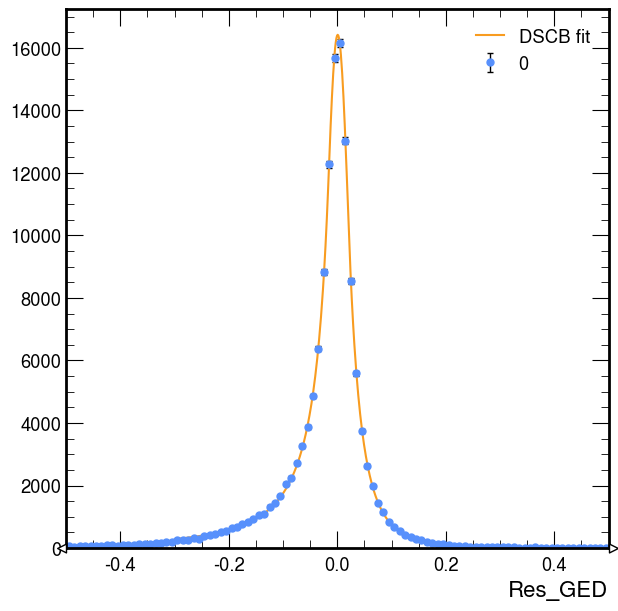

1


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


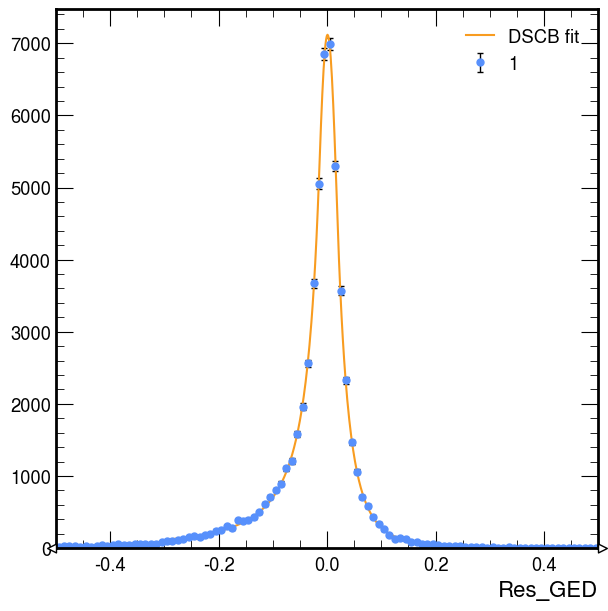

2


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


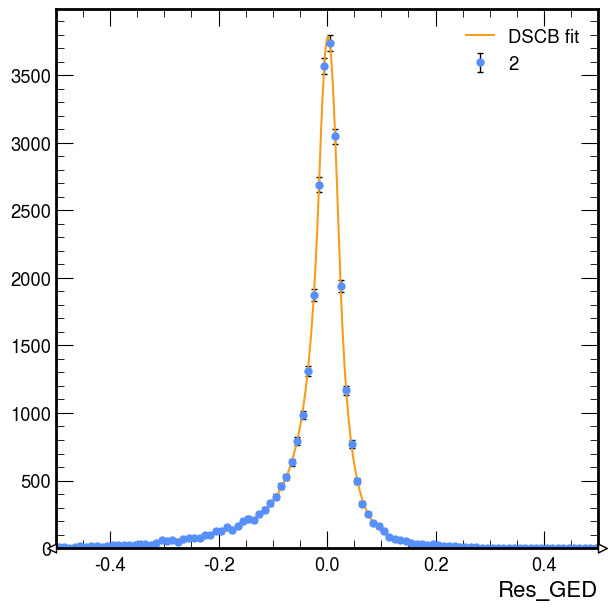

3


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


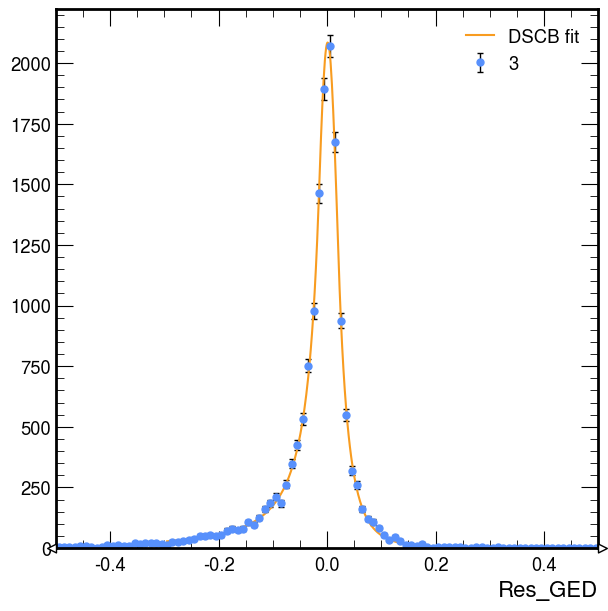

4


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


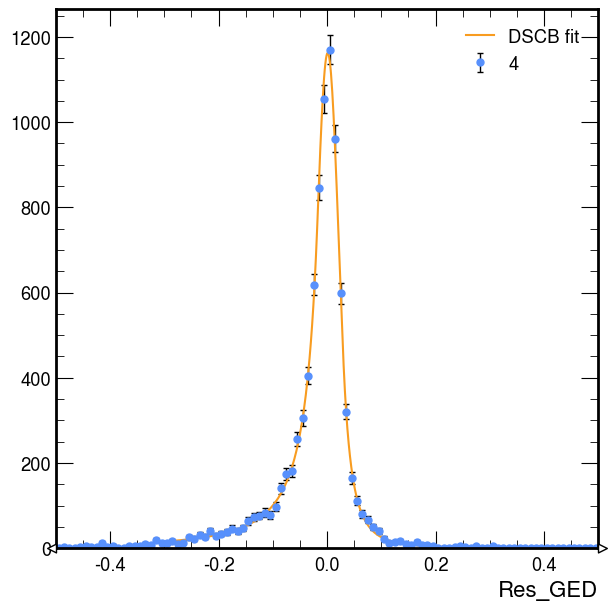

5


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


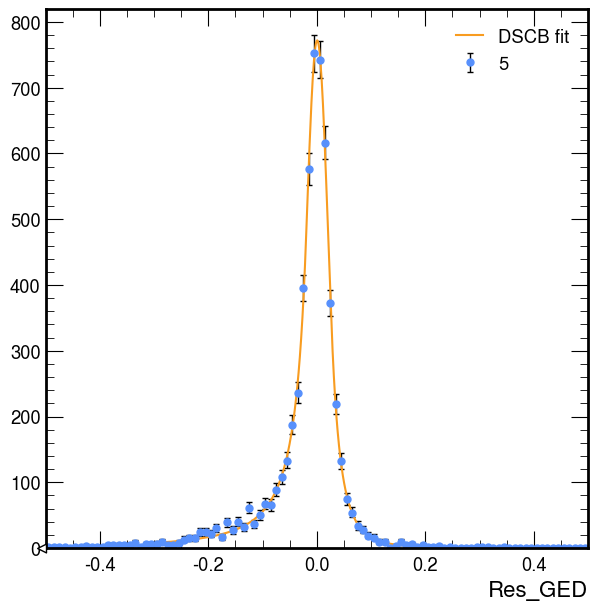

6


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


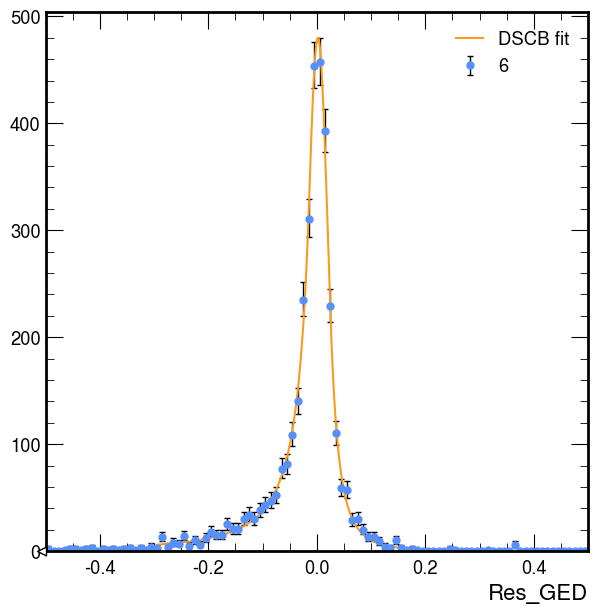

7


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


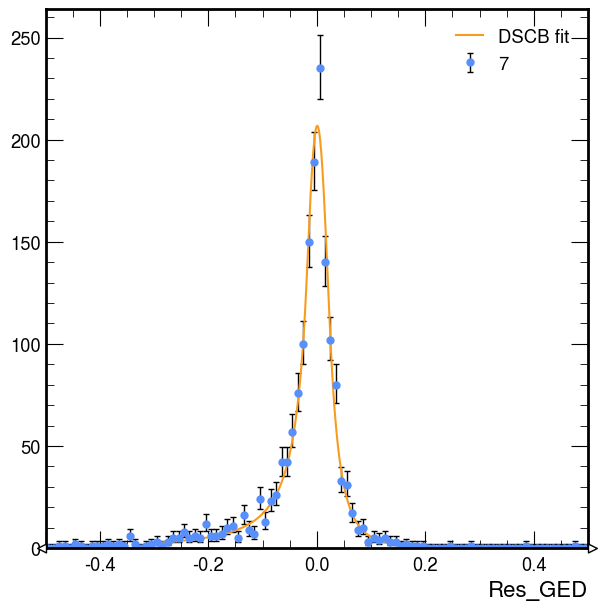

8


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


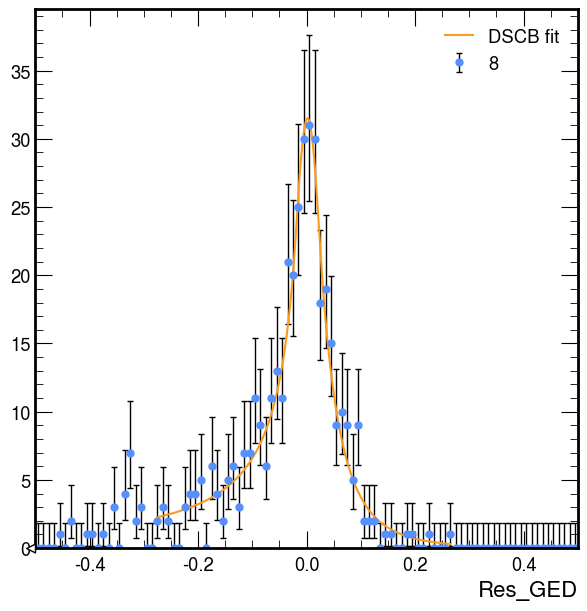

9


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


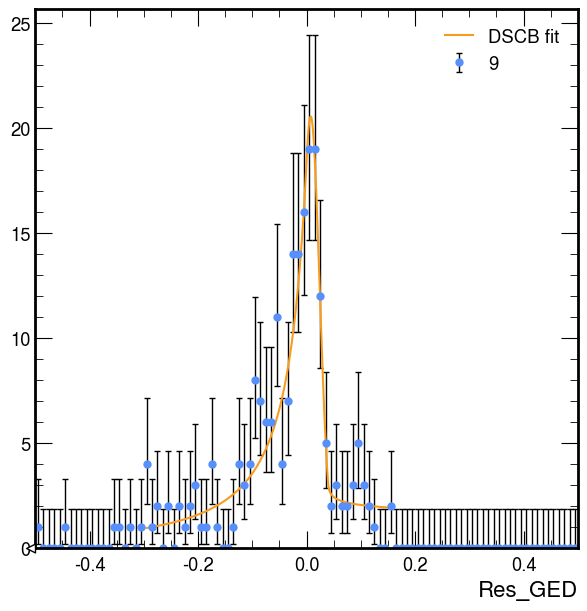

[{'pT bin index': 0,
  'genptbin_range': (0.0, 0.2),
  'fit_mean': 0.0006340026766898017,
  'fit_mean_unc': 0.00013691551185925484,
  'fit_sigma': 0.02089519157686148,
  'fit_sigma_unc': 0.00027070286085062066,
  'chi2/ndof': 2.811756668727427},
 {'pT bin index': 1,
  'genptbin_range': (0.2, 0.4),
  'fit_mean': 0.0007748068572933465,
  'fit_mean_unc': 0.00019902160857917468,
  'fit_sigma': 0.019442361704077333,
  'fit_sigma_unc': 0.0004016216926864816,
  'chi2/ndof': 2.041261235232765},
 {'pT bin index': 2,
  'genptbin_range': (0.4, 0.6),
  'fit_mean': 0.001641632267723905,
  'fit_mean_unc': 0.0002591525524969921,
  'fit_sigma': 0.020027990512210835,
  'fit_sigma_unc': 0.0004420014103023833,
  'chi2/ndof': 1.330327781972874},
 {'pT bin index': 3,
  'genptbin_range': (0.6, 0.8),
  'fit_mean': 0.000985466074177282,
  'fit_mean_unc': 0.0003376414197336238,
  'fit_sigma': 0.018995703616443566,
  'fit_sigma_unc': 0.0005950726293081291,
  'chi2/ndof': 2.262287125768265},
 {'pT bin index': 4,

In [37]:
from scipy.optimize import curve_fit

fit_data=[]

for data in first_data:
    print (data["ptbin_index"])
    plt.figure(figsize=(7, 7))
    mplhep.histplot( h_fit_lpt[data["ptbin_index"], :],histtype='errorbar', yerr=True,  fmt='o',capsize=2, ecolor='black', label=data["ptbin_index"])
    plt.legend()
    plt.xlim(plot_min, plot_max)
   

    mean0 = np.average(data["x_new_data"], weights=data["y_new_data"])
    sigma0 = np.sqrt(np.average((data["x_new_data"]-mean0)**2, weights=data["y_new_data"]))

   # [mean, sigma, nl, al, nr, ar, N]:  [0.0002642, 0.02177, 1, 0.2, 1, 0.2,data["y_new_data"].max()]
    initial_guess = [mean0, sigma0, 1, 0.2, 1, 0.2, data["y_new_data"].max()]

    lower = [data["x_new_data"].min(), 1e-5, 0.5, 0.05, 0.1, 0.05, 0]
    upper = [data["x_new_data"].max(), (data["x_new_data"].max()-data["x_new_data"].min()), 2, 1, 5, 2, 5*data["y_new_data"].max()]


    popt, pcov = curve_fit(double_cb, data["x_new_data"], data["y_new_data"], p0=initial_guess, sigma=data["yerr_new_data"], absolute_sigma=True, bounds=(lower, upper), maxfev=20000)
    perr = np.sqrt(np.diag(pcov))

    yp = double_cb(data["x_new_data"], *popt)

    eq = (data["y_new_data"]-yp)/(data["yerr_new_data"])
    chi2 = np.sum(eq**2)

    ndof = len(data["y_new_data"]) - len(popt)

    chi2ndof = chi2/ndof

    

    fit_mean = f"{popt[0]:.5f} ± {perr[0]:.5f}"
    fit_sigma = f"{popt[1]:.5f} ± {perr[1]:.5f}"

    fit_data.append({"pT bin index":data["ptbin_index"], "genptbin_range":data["genpt_bin"], "fit_mean": popt[0], "fit_mean_unc": perr[0], "fit_sigma":popt[1],"fit_sigma_unc":perr[1], "chi2/ndof":chi2ndof})
    # Smooth curve for display across the selected fit range.
    x_fit_plot = np.linspace(data["x_new_data"].min(), data["x_new_data"].max(), 500)
    plt.plot(x_fit_plot, double_cb(x_fit_plot, *popt), label="DSCB fit")
    plt.legend()
    plt.show()


fit_data  
